In [8]:
import pandas as pd

file='등급별 평균 및 표준편차.xlsx'


In [9]:
# 방법 1: MultiIndex 컬럼으로 처리
def load_with_multiindex(file_path):
    """
    MultiIndex 컬럼으로 데이터를 로드하는 방법
    """
    # header=[0,1]로 두 행을 모두 헤더로 사용
    dataframe1 = pd.read_excel(file_path, header=[0, 1], index_col=0)
    
    # 컬럼명 정리 (NaN 값들을 적절히 처리)
    dataframe1.columns = pd.MultiIndex.from_tuples([
        (col[0] if pd.notna(col[0]) else '', col[1] if pd.notna(col[1]) else '')
        for col in dataframe1.columns
    ])
    
    return dataframe1

In [10]:
df_multiindex = load_with_multiindex(file)
df_multiindex

매출액                         영업이익                \
                 mean(평균)      std(표준편차)          mean           std   
신용등급                                                                   
AAA         127409.692308  142596.149202  13167.461538  18678.247735   
AA+          82775.333333  108426.179506     24.000000   2900.866250   
AA          154436.785714  144304.494168  18647.642857  56867.248018   
AA-          66250.714286   62022.082883   1926.928571   2490.719095   
A+          107010.333333  218286.809618   5702.444444   9253.471310   
A            37692.714286   33433.782455   1396.714286   2281.891373   
A-           14586.333333   11545.729005    472.000000    488.496469   
BBB+         48268.500000   40857.971150   1660.000000   2000.729922   
BBB           7717.428571    4997.177499     72.857143    696.520980   
BBB-         10711.250000    4322.955808    426.500000    308.300178   
BB+           9396.750000    7448.898548  -1220.250000   2917.091859   
BB            5946.800000    5822.537479     72.400000    284.677537   
BB-           2677.000000    2553.354656     70.833333    168.178972   
B+            6580.200000    8704.941568    276.600000    451.314524   
B             5736.500000    2697.612370   -218.000000    349.310750   
B-            4176.500000    2082.429471    270.000000    148.492424   
CC            3411.000000            NaN   -696.000000           NaN   
C            26862.000000            NaN    206.000000           NaN   
NaN                   NaN            NaN           NaN           NaN   
NaN                   NaN            NaN           NaN           NaN   
NaN                   NaN            NaN           NaN           NaN   
NaN                   NaN            NaN           NaN           NaN   
등급별 데이터 수:            NaN            NaN           NaN           NaN   
AAA     13            NaN            NaN           NaN           NaN   
AA+      3            NaN            NaN           NaN           NaN   
AA       7            NaN            NaN           NaN           NaN   
AA-     10            NaN            NaN           NaN           NaN   
A+       9            NaN            NaN           NaN           NaN   
A        4            NaN            NaN           NaN           NaN   
A-       5            NaN            NaN           NaN           NaN   
BBB+     9            NaN            NaN           NaN           NaN   
BBB      5            NaN            NaN           NaN           NaN   
BBB-     2            NaN            NaN           NaN           NaN   
BB+      5            NaN            NaN           NaN           NaN   
BB       4            NaN            NaN           NaN           NaN   
BB-      5            NaN            NaN           NaN           NaN   
B+       5            NaN            NaN           NaN           NaN   
B        3            NaN            NaN           NaN           NaN   
B-       5            NaN            NaN           NaN           NaN   
CCC      4            NaN            NaN           NaN           NaN   
CC       1            NaN            NaN           NaN           NaN   
C        1            NaN            NaN           NaN           NaN   

                   당기순이익                          총자산                 \
                    mean           std           mean            std   
신용등급                                                                   
AAA          8501.461538  15158.748484  352196.307692  256789.888764   
AA+           171.666667   1747.328914  142381.666667  173189.703251   
AA          13936.928571  47440.503721  298366.285714  313481.907261   
AA-          -281.000000   5907.486762   70421.142857   73825.908785   
A+           3800.666667   6091.834391  125756.777778  237046.527721   
A            1042.142857   1688.586532   57263.285714   36626.800792   
A-           -618.666667   1177.018380   23126.000000   14952.282889   
BBB+          968.700000   1591.423405   71959.200000   73023

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (matplotlib에서 한글 표시용)
plt.rcParams['font.family'] = ['DejaVu Sans', 'Malgun Gothic']
plt.rcParams['axes.unicode_minus'] = False

In [15]:

class CompanyDataGenerator:
    def __init__(self, df_multiindex):
        """
        MultiIndex DataFrame을 입력받아 초기화
        """
        self.df = df_multiindex
        self.financial_metrics = [
            '매출액', '영업이익', '당기순이익', '총자산', '총부채', 
            '자본총계', '자본금', '영업활동현금흐름', '이자발생부채'
        ]
        # 음수가 되면 안 되는 지표들 (표준편차 조정 대상)
        self.positive_only_metrics = ['매출액', '총자산', '자본금', '자본총계']
        
    def _adjust_std_for_positive_metrics(self, mean_val, std_val, metric):
        """
        양수만 가능한 지표들의 표준편차를 조정
        평균값의 30%로 제한하여 음수 생성 방지
        """
        if metric in self.positive_only_metrics and mean_val > 0:
            # 평균의 30%를 최대 표준편차로 설정
            max_std = mean_val * 0.3
            adjusted_std = min(std_val, max_std)
            return adjusted_std
        return std_val
    
    def _generate_truncated_normal(self, mean_val, std_val, metric, percentile_range=(5, 95)):
        """
        지정된 퍼센타일 범위 내에서만 정규분포 값을 생성
        
        Parameters:
        - mean_val: 평균값
        - std_val: 표준편차
        - metric: 지표명
        - percentile_range: 퍼센타일 범위 (기본값: 5-95%)
        
        Returns:
        - 범위 내 생성된 값
        """
        # 표준편차 조정
        adjusted_std = self._adjust_std_for_positive_metrics(mean_val, std_val, metric)
        
        # 퍼센타일에 해당하는 Z-score 계산
        lower_percentile, upper_percentile = percentile_range
        lower_z = stats.norm.ppf(lower_percentile / 100.0)
        upper_z = stats.norm.ppf(upper_percentile / 100.0)
        
        # 실제 값의 범위 계산
        lower_bound = mean_val + lower_z * adjusted_std
        upper_bound = mean_val + upper_z * adjusted_std
        
        # 양수만 가능한 지표의 경우 하한값 조정
        if metric in self.positive_only_metrics:
            lower_bound = max(0.1, lower_bound)
        
        # 범위 내에서 균등분포로 값 생성 후 정규분포에 맞게 변환
        # 더 정확한 방법: truncated normal distribution 사용
        from scipy.stats import truncnorm
        
        # truncnorm의 a, b는 표준화된 값 (Z-score)
        a = (lower_bound - mean_val) / adjusted_std
        b = (upper_bound - mean_val) / adjusted_std
        
        # truncated normal distribution에서 샘플링
        generated_value = truncnorm.rvs(a, b, loc=mean_val, scale=adjusted_std)
        
        return generated_value
        
    def generate_company_data(self, credit_grade, company_name=None, seed=None, percentile_range=(5, 95)):
        """
        특정 신용등급을 기반으로 새로운 기업 데이터 생성 (5-95 퍼센타일 범위)
        
        Parameters:
        - credit_grade: 신용등급 (예: 'AAA', 'AA+', 'BBB' 등)
        - company_name: 생성할 기업명 (선택사항)
        - seed: 랜덤 시드 (재현가능한 결과를 위해)
        - percentile_range: 생성할 값의 퍼센타일 범위 (기본값: 5-95%)
        
        Returns:
        - 생성된 기업 데이터 (Series)
        """
        if seed is not None:
            np.random.seed(seed)
            
        if credit_grade not in self.df.index:
            raise ValueError(f"신용등급 '{credit_grade}'이 데이터에 없습니다. 사용가능한 등급: {list(self.df.index)}")
        
        # 해당 등급의 통계 데이터 가져오기
        grade_data = self.df.loc[credit_grade]
        
        # 새로운 기업 데이터 생성
        generated_data = {}
        
        for metric in self.financial_metrics:
            try:
                mean_val = grade_data[(metric, 'mean')]
                std_val = grade_data[(metric, 'std')]
                
                # NaN 값 처리
                if pd.isna(mean_val) or pd.isna(std_val):
                    generated_data[metric] = np.nan
                    continue
                
                # 5-95 퍼센타일 범위에서 값 생성
                generated_value = self._generate_truncated_normal(
                    mean_val, std_val, metric, percentile_range
                )
                
                generated_data[metric] = generated_value
                
            except KeyError:
                print(f"Warning: {metric} 데이터를 찾을 수 없습니다.")
                generated_data[metric] = np.nan
        
        # Series로 변환
        company_data = pd.Series(generated_data)
        company_data.name = company_name or f"Generated_Company_{credit_grade}"
        
        return company_data
    
    def generate_multiple_companies(self, credit_grade, num_companies=10, name_prefix="Company", percentile_range=(5, 95)):
        """
        동일한 신용등급으로 여러 기업 데이터 생성
        """
        companies = []
        for i in range(num_companies):
            company_name = f"{name_prefix}_{credit_grade}_{i+1:02d}"
            company_data = self.generate_company_data(
                credit_grade, company_name, seed=i, percentile_range=percentile_range
            )
            companies.append(company_data)
        
        return pd.DataFrame(companies)
    
    def generate_companies_all_grades(self, num_per_grade=10, name_prefix="Company", percentile_range=(5, 95)):
        """
        모든 신용등급에 대해 기업 데이터 생성
        
        Parameters:
        - num_per_grade: 각 등급별 생성할 기업 수
        - name_prefix: 기업명 접두사
        - percentile_range: 퍼센타일 범위 (기본값: 5-95%)
        
        Returns:
        - 모든 등급의 기업 데이터가 포함된 DataFrame
        """
        all_companies = []
        
        for grade in self.df.index:
            try:
                grade_companies = self.generate_multiple_companies(
                    grade, num_per_grade, name_prefix, percentile_range
                )
                # 신용등급 컬럼 추가
                grade_companies['신용등급'] = grade
                all_companies.append(grade_companies)
                print(f"{grade} 등급: {num_per_grade}개 기업 생성 완료 (퍼센타일 범위: {percentile_range[0]}-{percentile_range[1]}%)")
            except Exception as e:
                print(f"{grade} 등급 생성 중 오류: {e}")
        
        if all_companies:
            result_df = pd.concat(all_companies, ignore_index=True)
            # 신용등급 컬럼을 앞쪽으로 이동
            cols = ['신용등급'] + [col for col in result_df.columns if col != '신용등급']
            result_df = result_df[cols]
            return result_df
        else:
            return pd.DataFrame()
    
    def save_to_csv(self, data, filename, folder_path="generated_data"):
        """
        생성된 데이터를 CSV 파일로 저장
        
        Parameters:
        - data: 저장할 DataFrame 또는 Series
        - filename: 파일명 (확장자 제외)
        - folder_path: 저장할 폴더 경로
        """
        # 폴더가 없으면 생성
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
        
        # 파일 경로 생성
        file_path = os.path.join(folder_path, f"{filename}.csv")
        
        # CSV로 저장
        if isinstance(data, pd.Series):
            data.to_csv(file_path, encoding='utf-8-sig')
        else:
            data.to_csv(file_path, index=False, encoding='utf-8-sig')
        
        print(f"데이터가 저장되었습니다: {file_path}")
        return file_path

    def plot_distribution_comparison(self, credit_grade, num_samples=1000, save_samples=False, 
                                   filename=None, percentile_range=(5, 95)):
        """
        원본 통계와 생성된 데이터의 분포 비교 시각화 (5-95 퍼센타일 범위)
        
        Parameters:
        - credit_grade: 신용등급
        - num_samples: 생성할 샘플 수 (기본 1000)
        - save_samples: 생성된 샘플 데이터를 CSV로 저장할지 여부
        - filename: CSV 파일명 (지정하지 않으면 자동 생성)
        - percentile_range: 퍼센타일 범위 (기본값: 5-95%)
        """
        # 여러 샘플 생성 (5-95 퍼센타일 범위)
        samples = self.generate_multiple_companies(
            credit_grade, num_samples, "Sample", percentile_range
        )
        
        # 샘플 데이터 저장 (선택사항)
        if save_samples:
            if filename is None:
                filename = f"truncated_samples_{credit_grade}_{num_samples}_p{percentile_range[0]}-{percentile_range[1]}"
            
            # 신용등급 컬럼 추가
            samples_with_grade = samples.copy()
            samples_with_grade['신용등급'] = credit_grade
            
            # CSV로 저장
            saved_path = self.save_to_csv(samples_with_grade, filename)
            print(f"절단된 분포 샘플 데이터 저장 완료: {saved_path}")
        
        # 주요 지표들만 선택해서 시각화
        key_metrics = ['매출액', '영업이익', '당기순이익', '총자산']
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()
        
        for i, metric in enumerate(key_metrics):
            if i < len(axes):
                ax = axes[i]
                
                # 원본 통계
                original_mean = self.df.loc[credit_grade, (metric, 'mean')]
                original_std = self.df.loc[credit_grade, (metric, 'std')]
                
                if not (pd.isna(original_mean) or pd.isna(original_std)):
                    # 조정된 표준편차
                    adjusted_std = self._adjust_std_for_positive_metrics(original_mean, original_std, metric)
                    
                    # 생성된 데이터 히스토그램
                    generated_values = samples[metric].dropna()
                    ax.hist(generated_values, bins=50, alpha=0.7, density=True, 
                           color='skyblue', label=f'Generated Data ({percentile_range[0]}-{percentile_range[1]}%)')
                    
                    # 절단된 정규분포의 이론적 곡선
                    from scipy.stats import truncnorm
                    
                    # 퍼센타일 범위 계산
                    lower_z = stats.norm.ppf(percentile_range[0] / 100.0)
                    upper_z = stats.norm.ppf(percentile_range[1] / 100.0)
                    lower_bound = original_mean + lower_z * adjusted_std
                    upper_bound = original_mean + upper_z * adjusted_std
                    
                    if metric in self.positive_only_metrics:
                        lower_bound = max(0.1, lower_bound)
                    
                    # 절단된 정규분포 곡선
                    x = np.linspace(lower_bound, upper_bound, 100)
                    a = (lower_bound - original_mean) / adjusted_std
                    b = (upper_bound - original_mean) / adjusted_std
                    truncated_dist = truncnorm.pdf(x, a, b, loc=original_mean, scale=adjusted_std)
                    ax.plot(x, truncated_dist, 'r-', linewidth=2, label='Truncated Normal')
                    
                    # 원본 이론적 분포도 표시 (전체 범위)
                    x_full = np.linspace(generated_values.min() * 0.8, generated_values.max() * 1.2, 100)
                    original_dist = stats.norm.pdf(x_full, original_mean, adjusted_std)
                    ax.plot(x_full, original_dist, 'g--', linewidth=1, alpha=0.5, label='Original Normal')
                    
                    # 원본 평균선
                    ax.axvline(original_mean, color='red', linestyle='--', 
                              label=f'Mean: {original_mean:.0f}')
                    
                    # 퍼센타일 경계선
                    ax.axvline(lower_bound, color='orange', linestyle=':', alpha=0.7,
                              label=f'{percentile_range[0]}% bound')
                    ax.axvline(upper_bound, color='orange', linestyle=':', alpha=0.7,
                              label=f'{percentile_range[1]}% bound')
                    
                    ax.set_title(f'{metric} Distribution ({credit_grade} Grade)\nTruncated {percentile_range[0]}-{percentile_range[1]}%')
                    ax.set_xlabel('Value')
                    ax.set_ylabel('Density')
                    ax.legend(fontsize=8)
                    ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # 통계 요약
        print(f"\n=== {credit_grade} 등급 절단된 분포 데이터 통계 요약 (퍼센타일: {percentile_range[0]}-{percentile_range[1]}%) ===")
        for metric in key_metrics:
            original_mean = self.df.loc[credit_grade, (metric, 'mean')]
            original_std = self.df.loc[credit_grade, (metric, 'std')]
            
            if not pd.isna(original_mean):
                adjusted_std = self._adjust_std_for_positive_metrics(original_mean, original_std, metric)
                generated_mean = samples[metric].mean()
                generated_std = samples[metric].std()
                
                # 이론적 범위 계산
                lower_z = stats.norm.ppf(percentile_range[0] / 100.0)
                upper_z = stats.norm.ppf(percentile_range[1] / 100.0)
                theoretical_lower = original_mean + lower_z * adjusted_std
                theoretical_upper = original_mean + upper_z * adjusted_std
                
                # 실제 생성된 데이터의 범위
                actual_min = samples[metric].min()
                actual_max = samples[metric].max()
                
                print(f"\n{metric}:")
                print(f"  원본    - 평균: {original_mean:>10.0f}, 표준편차: {original_std:>10.0f}")
                print(f"  조정됨  - 평균: {original_mean:>10.0f}, 표준편차: {adjusted_std:>10.0f}")
                print(f"  생성됨  - 평균: {generated_mean:>10.0f}, 표준편차: {generated_std:>10.0f}")
                print(f"  이론범위 - 최소: {theoretical_lower:>10.0f}, 최대: {theoretical_upper:>10.0f}")
                print(f"  실제범위 - 최소: {actual_min:>10.0f}, 최대: {actual_max:>10.0f}")
        
        return samples  # 생성된 샘플 데이터 반환


데이터가 저장되었습니다: generated_data\truncated_samples_AAA_1000_p10-90.csv
절단된 분포 샘플 데이터 저장 완료: generated_data\truncated_samples_AAA_1000_p10-90.csv


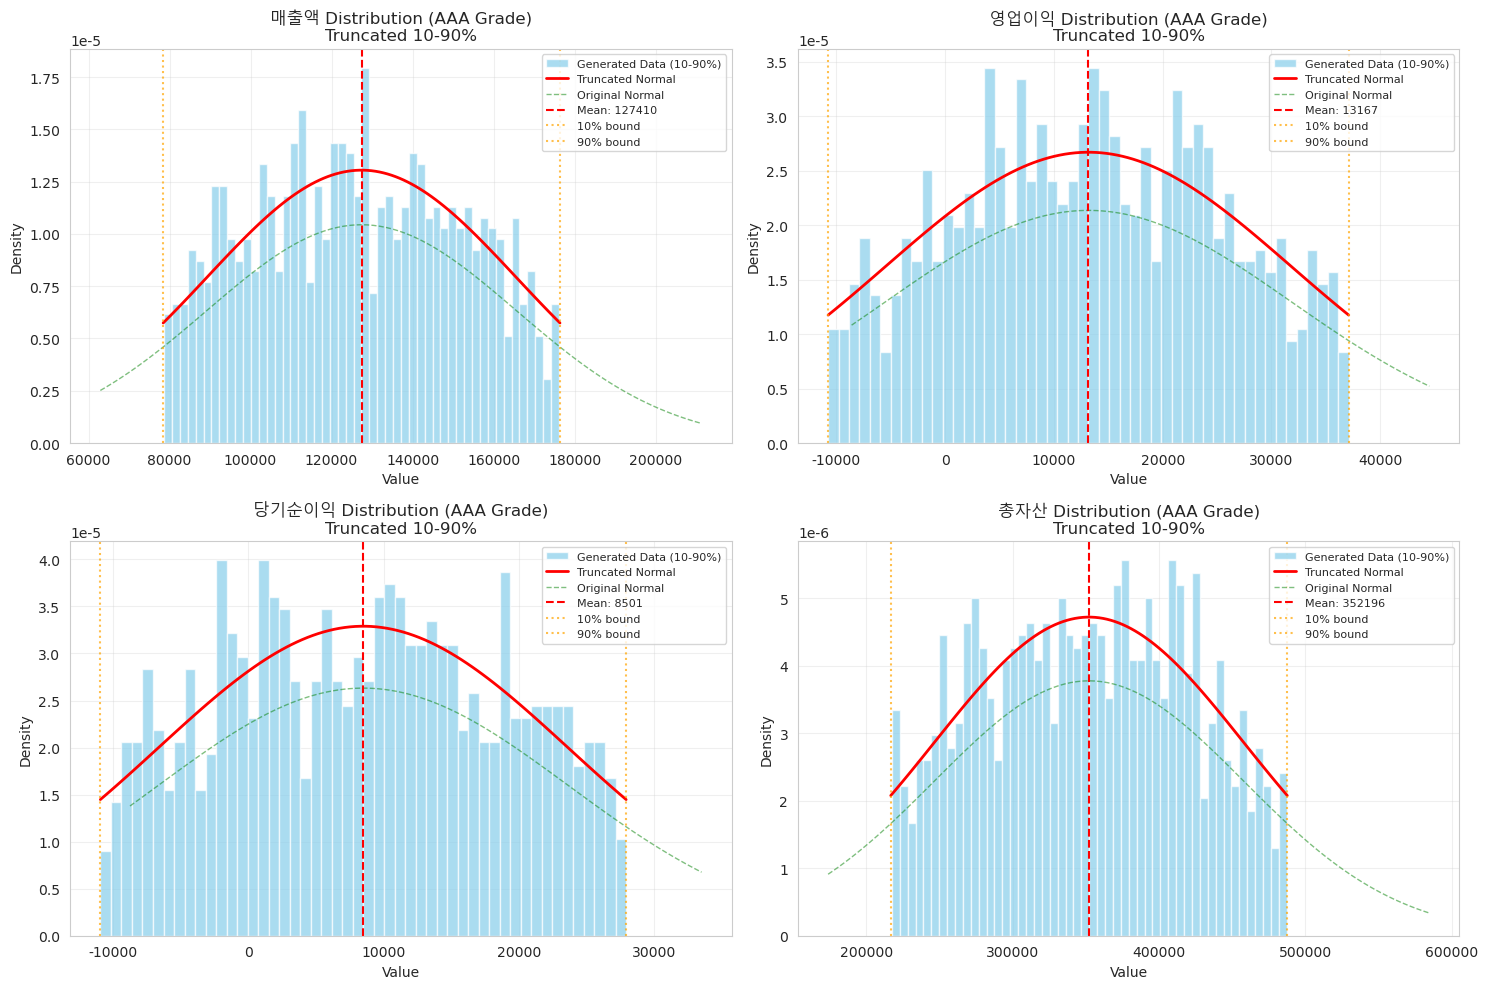


=== AAA 등급 절단된 분포 데이터 통계 요약 (퍼센타일: 10-90%) ===

매출액:
  원본    - 평균:     127410, 표준편차:     142596
  조정됨  - 평균:     127410, 표준편차:      38223
  생성됨  - 평균:     126318, 표준편차:      25507
  이론범위 - 최소:      78425, 최대:     176394
  실제범위 - 최소:      78648, 최대:     176125

영업이익:
  원본    - 평균:      13167, 표준편차:      18678
  조정됨  - 평균:      13167, 표준편차:      18678
  생성됨  - 평균:      13165, 표준편차:      12093
  이론범위 - 최소:     -10770, 최대:      37105
  실제범위 - 최소:     -10763, 최대:      37100

당기순이익:
  원본    - 평균:       8501, 표준편차:      15159
  조정됨  - 평균:       8501, 표준편차:      15159
  생성됨  - 평균:       8492, 표준편차:      10184
  이론범위 - 최소:     -10925, 최대:      27928
  실제범위 - 최소:     -10917, 최대:      27919

총자산:
  원본    - 평균:     352196, 표준편차:     256790
  조정됨  - 평균:     352196, 표준편차:     105659
  생성됨  - 평균:     350433, 표준편차:      70019
  이론범위 - 최소:     216789, 최대:     487604
  실제범위 - 최소:     217514, 최대:     487198


In [16]:
def example_usage(file_path):
    """
    사용 예시 (5-95 퍼센타일 범위)
    """
    # 데이터 로드
    df = load_with_multiindex(file_path)
    
    # 제너레이터 생성
    generator = CompanyDataGenerator(df)
    
    # 단일 기업 생성 (5-95 퍼센타일 범위)
    # company = generator.generate_company_data('AAA', 'Test_Company_001', percentile_range=(5, 95))
    # generator.save_to_csv(company, 'single_company_AAA_truncated')
    
    # 특정 등급의 여러 기업 생성 (5-95 퍼센타일 범위)
    # companies_aaa = generator.generate_multiple_companies('AAA', 50, percentile_range=(5, 95))
    # generator.save_to_csv(companies_aaa, 'companies_AAA_grade_truncated')
    
    # 모든 등급의 기업 생성 (5-95 퍼센타일 범위)
    # all_companies = generator.generate_companies_all_grades(num_per_grade=100, percentile_range=(20, 80))
    # generator.save_to_csv(all_companies, 'all_companies_dataset')
    
    # 분포 분석 (5-95 퍼센타일 범위)
    # samples = generator.plot_distribution_comparison('AAA', num_samples=1000, 
    #                                                 save_samples=True, percentile_range=(5, 95))
    
    # 다른 퍼센타일 범위도 가능 (예: 10-90%)
    samples = generator.plot_distribution_comparison(
        'AAA', num_samples=1000, save_samples=True, percentile_range=(10, 90))
    pass

example_usage(file)